In [34]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv('cleaned_sales_data.csv')

In [36]:
# Total Profit
df['Total_Profit'] = df['Sales'] - df['Cost']

# Profit Per Unit
df['Profit_Per_Unit'] = df['Total_Profit'] / df['Units']

# Gross Margin %
df['Gross_Margin_%'] = (df['Total_Profit'] / df['Sales']) * 100

In [37]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product Name,Sales,Units,Gross Profit,Cost,Validation_Status,Profit,Total_Profit,Profit_Per_Unit,Gross_Margin_%
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,...,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,Valid,4.22,4.22,2.11,64.923077
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,Valid,4.90,4.90,2.45,65.333333
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,Valid,7.47,7.47,2.49,71.346705
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,Valid,7.50,7.50,2.50,69.444444
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,Valid,7.35,7.35,2.45,65.333333


## Rank product by gross profit and margin

In [38]:
# Rank by Gross Profit (Highest = Rank 1)
df['Gross_Profit_Rank'] = df['Total_Profit'].rank(method='dense', ascending=False)

# Rank by Gross Margin % (Highest = Rank 1)
df['Gross_Margin_Rank'] = df['Gross_Margin_%'].rank(method='dense', ascending=False)

## View Top Products by Gross Profit

In [39]:
df.sort_values('Gross_Profit_Rank').tail(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Validation_Status,Profit,Total_Profit,Profit_Per_Unit,Gross_Margin_%,Gross_Profit_Rank,Gross_Margin_Rank
1982,1983,US-2021-166961-OTH-KAZ-38000,27-12-2024,23-06-2027,Standard Class,166961,United States,Moreno Valley,California,92553,...,1,0.25,3.0,Valid,0.25,0.25,0.25,7.692308,123.0,19.0
785,786,US-2021-116932-OTH-KAZ-38000,21-07-2024,15-01-2027,Standard Class,116932,United States,San Francisco,California,94122,...,1,0.25,3.0,Valid,0.25,0.25,0.25,7.692308,123.0,19.0
7348,7349,US-2024-109211-OTH-KAZ-38000,04-04-2025,01-10-2029,Standard Class,109211,United States,New York City,New York,10011,...,1,0.25,3.0,Valid,0.25,0.25,0.25,7.692308,123.0,19.0


## View Top Products by Gross Margin %

In [40]:
df.sort_values('Gross_Margin_Rank').tail(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Validation_Status,Profit,Total_Profit,Profit_Per_Unit,Gross_Margin_%,Gross_Profit_Rank,Gross_Margin_Rank
2402,2403,US-2022-161263-OTH-KAZ-38000,16-04-2024,12-10-2027,Standard Class,161263,United States,Toledo,Ohio,43615,...,3,0.75,9.0,Valid,0.75,0.75,0.25,7.692308,118.0,19.0
4104,4105,US-2022-128587-OTH-KAZ-38000,24-12-2024,21-06-2028,Standard Class,128587,United States,Springfield,Missouri,65807,...,2,0.50,6.0,Valid,0.50,0.50,0.25,7.692308,122.0,19.0
5464,5465,US-2023-132094-OTH-KAZ-38000,26-08-2025,22-02-2029,Standard Class,132094,United States,Philadelphia,Pennsylvania,19140,...,3,0.75,9.0,Valid,0.75,0.75,0.25,7.692308,118.0,19.0


## Product-Level Profitability Analysis
- High-profit / high-margin products
- High-sales / low-margin products
- Low-sales / low-profit products

In [41]:
avg_sales = df['Sales'].mean()
avg_profit = df['Total_Profit'].mean()
avg_margin = df['Gross_Margin_%'].mean()

# High-Profit / High-Margin
high_profit_high_margin = df[
    (df['Total_Profit'] > avg_profit) &
    (df['Gross_Margin_%'] > avg_margin)
]

# High-Sales / Low-Margin
high_sales_low_margin = df[
    (df['Sales'] > avg_sales) &
    (df['Gross_Margin_%'] < avg_margin)
]

# Low-Sales / Low-Profit
low_sales_low_profit = df[
    (df['Sales'] < avg_sales) &
    (df['Total_Profit'] < avg_profit)
]

## To see the products in each category

In [42]:
print("High-Profit / High-Margin")
print(high_profit_high_margin[['Product Name','Sales','Total_Profit','Gross_Margin_%']])

print("High-Sales / Low-Margin")
print(high_sales_low_margin[['Product Name','Sales','Total_Profit','Gross_Margin_%']])

print("Low-Sales / Low-Profit")
print(low_sales_low_profit[['Product Name','Sales','Total_Profit','Gross_Margin_%']])

High-Profit / High-Margin
                            Product Name  Sales  Total_Profit  Gross_Margin_%
5         Wonka Bar -Scrumdiddlyumptious  32.40         22.50       69.444444
12        Wonka Bar -Scrumdiddlyumptious  14.40         10.00       69.444444
22     Wonka Bar - Nutty Crunch Surprise  20.94         14.94       71.346705
28        Wonka Bar -Scrumdiddlyumptious  25.20         17.50       69.444444
30     Wonka Bar - Nutty Crunch Surprise  17.45         12.45       71.346705
...                                  ...    ...           ...             ...
10163     Wonka Bar -Scrumdiddlyumptious  18.00         12.50       69.444444
10164          Wonka Bar - Fudge Mallows  14.40          9.60       66.666667
10173  Wonka Bar - Nutty Crunch Surprise  13.96          9.96       71.346705
10175     Wonka Bar -Scrumdiddlyumptious  28.80         20.00       69.444444
10183     Wonka Bar -Scrumdiddlyumptious  28.80         20.00       69.444444

[2429 rows x 4 columns]
High-Sales / 

## Aggregate Metrics by Division

In [43]:
division_summary = df.groupby('Division').agg(
    Revenue=('Sales', 'sum'),
    Profit=('Total_Profit', 'sum'),
    Avg_Margin=('Gross_Margin_%', 'mean')
).reset_index()

print(division_summary)

    Division    Revenue    Profit  Avg_Margin
0  Chocolate  131692.90  88824.62   67.458162
1      Other    9663.25   4333.45   37.672457
2      Sugar     427.48    284.73   57.689001


## Compare Average Margin by Division

In [44]:
division_summary.sort_values('Avg_Margin', ascending=False)

,Division,Revenue,Profit,Avg_Margin
0,Chocolate,131692.90,88824.62,67.458162
2,Sugar,427.48,284.73,57.689001
1,Other,9663.25,4333.45,37.672457


## Compare Revenue vs Profit Imbalance

In [45]:
division_summary['Profit_to_Revenue_%'] = (
    division_summary['Profit'] / division_summary['Revenue']
) * 100

division_summary.sort_values('Profit_to_Revenue_%')

,Division,Revenue,Profit,Avg_Margin,Profit_to_Revenue_%
1,Other,9663.25,4333.45,37.672457,44.844643
2,Sugar,427.48,284.73,57.689001,66.606625
0,Chocolate,131692.90,88824.62,67.458162,67.448298


## • Identifying divisions with:
- Strong financial efficiency
- Structural margin issues

In [46]:
division_summary['Category'] = 'Average'

division_summary.loc[
    (division_summary['Avg_Margin'] > avg_margin) &
    (division_summary['Profit'] > division_summary['Profit'].mean()),
    'Category'
] = 'Strong Financial Efficiency'

division_summary.loc[
    (division_summary['Revenue'] > division_summary['Revenue'].mean()) &
    (division_summary['Avg_Margin'] < avg_margin),
    'Category'
] = 'Structural Margin Issue'

print(division_summary[['Division','Revenue','Profit','Avg_Margin','Category']])

    Division    Revenue    Profit  Avg_Margin                     Category
0  Chocolate  131692.90  88824.62   67.458162  Strong Financial Efficiency
1      Other    9663.25   4333.45   37.672457                      Average
2      Sugar     427.48    284.73   57.689001                      Average


## 80% Revenue Contribution

In [47]:
revenue_pareto = df.groupby('Product Name')['Sales'].sum().reset_index()

revenue_pareto = revenue_pareto.sort_values('Sales', ascending=False)

revenue_pareto['Cum_Revenue_%'] = (
    revenue_pareto['Sales'].cumsum() /
    revenue_pareto['Sales'].sum()
) * 100

products_80_revenue = revenue_pareto[revenue_pareto['Cum_Revenue_%'] <= 80]

revenue_percentage = (
    len(products_80_revenue) / len(revenue_pareto)
) * 100

print(f"{revenue_percentage:.2f}% of products generate 80% of revenue")

26.67% of products generate 80% of revenue


## 80% Profit contribution

In [48]:
profit_pareto = df.groupby('Product Name')['Total_Profit'].sum().reset_index()

profit_pareto = profit_pareto.sort_values(
    'Total_Profit',
    ascending=False
)

profit_pareto['Cum_Profit_%'] = (
    profit_pareto['Total_Profit'].cumsum() /
    profit_pareto['Total_Profit'].sum()
) * 100

products_80_profit = profit_pareto[
    profit_pareto['Cum_Profit_%'] <= 80
]

profit_percentage = (
    len(products_80_profit) / len(profit_pareto)
) * 100

print(f"{profit_percentage:.2f}% of products generate 80% of profit")

26.67% of products generate 80% of profit


In [49]:
print(f"Products contributing 80% Revenue: {len(products_80_revenue)} ({revenue_percentage:.2f}%)")
print(f"Products contributing 80% Profit: {len(products_80_profit)} ({profit_percentage:.2f}%)")

Products contributing 80% Revenue: 4 (26.67%)
Products contributing 80% Profit: 4 (26.67%)


## Congestion-Prone States/Regions
(States handling unusually high sales volume or revenue)

In [50]:
state_summary = df.groupby('State/Province').agg(
    Revenue=('Sales', 'sum'),
    Units_Sold=('Units', 'sum'),
    Profit=('Total_Profit', 'sum')
).reset_index()

congestion_prone = state_summary[
    state_summary['Revenue'] > state_summary['Revenue'].mean()
]

print(congestion_prone.sort_values('Revenue', ascending=False))

    State/Province   Revenue  Units_Sold    Profit
5       California  27917.40        7667  18479.42
34        New York  15541.03        4224  10222.44
51           Texas  13416.09        3724   8909.53
43    Pennsylvania   8027.03        2153   5225.47
55      Washington   6921.15        1883   4566.64
13        Illinois   6898.96        1845   4557.68
39            Ohio   6768.95        1759   4413.03
10         Florida   4804.02        1379   3207.11
2          Arizona   3587.55         862   2290.11
36  North Carolina   3450.86         983   2331.16
23        Michigan   3331.00         946   2236.21
54        Virginia   3177.84         893   2080.84
11         Georgia   2692.84         705   1751.32
6         Colorado   2544.91         693   1694.63


## Over-Dependency Risk Analysis
(Too much revenue coming from a small number of states/regions)

In [51]:
state_summary = state_summary.sort_values('Revenue', ascending=False)

state_summary['Revenue_%'] = (
    state_summary['Revenue'] /
    state_summary['Revenue'].sum()
) * 100

state_summary['Cumulative_Revenue_%'] = (
    state_summary['Revenue_%'].cumsum()
)

print(state_summary)

               State/Province   Revenue  Units_Sold    Profit  Revenue_%  \
5                  California  27917.40        7667  18479.42  19.690143   
34                   New York  15541.03        4224  10222.44  10.961089   
51                      Texas  13416.09        3724   8909.53   9.462369   
43               Pennsylvania   8027.03        2153   5225.47   5.661465   
55                 Washington   6921.15        1883   4566.64   4.881487   
13                   Illinois   6898.96        1845   4557.68   4.865837   
39                       Ohio   6768.95        1759   4413.03   4.774141   
10                    Florida   4804.02        1379   3207.11   3.388276   
2                     Arizona   3587.55         862   2290.11   2.530299   
36             North Carolina   3450.86         983   2331.16   2.433892   
23                   Michigan   3331.00         946   2236.21   2.349354   
54                   Virginia   3177.84         893   2080.84   2.241331   
11          

## States Contributing 80% of Revenue

In [52]:
top_states = state_summary[
    state_summary['Cumulative_Revenue_%'] <= 80
]

print(top_states[['State/Province', 'Revenue_%']])

    State/Province  Revenue_%
5       California  19.690143
34        New York  10.961089
51           Texas   9.462369
43    Pennsylvania   5.661465
55      Washington   4.881487
13        Illinois   4.865837
39            Ohio   4.774141
10         Florida   3.388276
2          Arizona   2.530299
36  North Carolina   2.433892
23        Michigan   2.349354
54        Virginia   2.241331
11         Georgia   1.899260
6         Colorado   1.794925
50       Tennessee   1.681125


## Percentage of States Generating 80% Revenue

In [53]:
dependency_percentage = (
    len(top_states) / len(state_summary)
) * 100

print(f"{dependency_percentage:.2f}% of states generate 80% of revenue")

25.42% of states generate 80% of revenue


## Cost vs sales scatter analysis

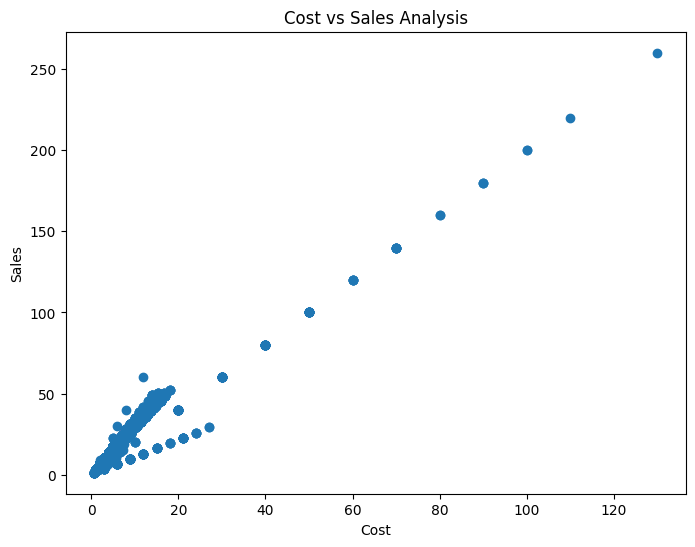

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(df['Cost'], df['Sales'])

plt.xlabel('Cost')
plt.ylabel('Sales')
plt.title('Cost vs Sales Analysis')

plt.show()

## Add Profitability Reference Line

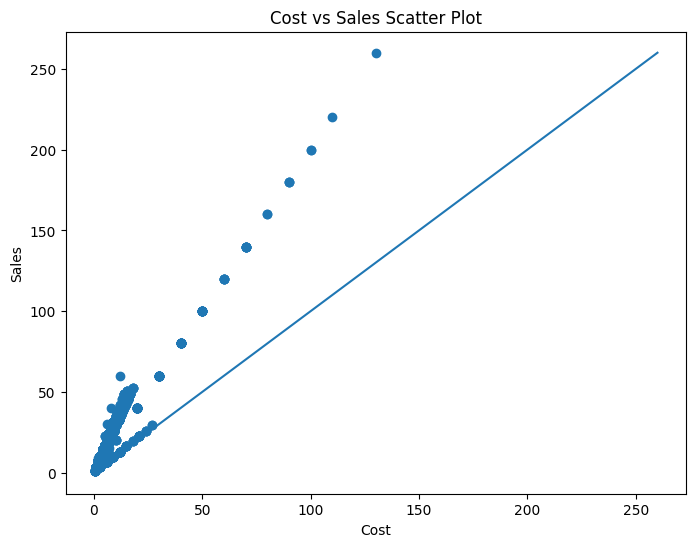

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(df['Cost'], df['Sales'])

max_val = max(df['Cost'].max(), df['Sales'].max())
plt.plot([0, max_val], [0, max_val])

plt.xlabel('Cost')
plt.ylabel('Sales')
plt.title('Cost vs Sales Scatter Plot')

plt.show()

## Corelation between sales and cost

In [56]:
correlation = df['Cost'].corr(df['Sales'])
print("Correlation:", round(correlation, 2))

Correlation: 0.96


##  Flag products needing:
- Repricing
- Cost renegotiation
- Discontinuation review

In [57]:
avg_sales = df['Sales'].mean()
avg_profit = df['Total_Profit'].mean()
avg_margin = df['Gross_Margin_%'].mean()

df['Recommendation'] = 'Healthy'

# Repricing Needed: High sales but low margin
df.loc[
    (df['Sales'] > avg_sales) &
    (df['Gross_Margin_%'] < avg_margin),
    'Recommendation'
] = 'Repricing Required'

# Cost Renegotiation: High sales but below-average profit
df.loc[
    (df['Sales'] > avg_sales) &
    (df['Total_Profit'] < avg_profit),
    'Recommendation'
] = 'Cost Renegotiation'

# Discontinuation Review: Low sales and low profit
df.loc[
    (df['Sales'] < avg_sales) &
    (df['Total_Profit'] < avg_profit),
    'Recommendation'
] = 'Discontinuation Review'

print(df[['Product Name','Sales','Total_Profit',
          'Gross_Margin_%','Recommendation']])

                            Product Name  Sales  Total_Profit  Gross_Margin_%  \
0             Wonka Bar - Milk Chocolate   6.50          4.22       64.923077   
1      Wonka Bar - Triple Dazzle Caramel   7.50          4.90       65.333333   
2      Wonka Bar - Nutty Crunch Surprise  10.47          7.47       71.346705   
3         Wonka Bar -Scrumdiddlyumptious  10.80          7.50       69.444444   
4      Wonka Bar - Triple Dazzle Caramel  11.25          7.35       65.333333   
...                                  ...    ...           ...             ...   
10189         Wonka Bar - Milk Chocolate   9.75          6.33       64.923077   
10190  Wonka Bar - Nutty Crunch Surprise   6.98          4.98       71.346705   
10191     Wonka Bar -Scrumdiddlyumptious  10.80          7.50       69.444444   
10192  Wonka Bar - Triple Dazzle Caramel  26.25         17.15       65.333333   
10193     Wonka Bar -Scrumdiddlyumptious  10.80          7.50       69.444444   

               Recommendati

In [58]:
print(df['Recommendation'].value_counts())

Recommendation
Discontinuation Review    6096
Healthy                   2429
Repricing Required        1638
Cost Renegotiation          31
Name: count, dtype: int64


### Percentage breakdown

In [59]:
(df['Recommendation'].value_counts(normalize=True) * 100).round(2)

Recommendation
Discontinuation Review    59.80
Healthy                   23.83
Repricing Required        16.07
Cost Renegotiation         0.30
Name: proportion, dtype: float64

In [60]:
df.to_csv("cleaned_sales_data2.csv", index=False)